 # requirements

In [ ]:
import math
import itertools
import time
from datetime import timedelta, datetime
import numpy as np
import pandas as pd
#Graph
import seaborn  as sns
import matplotlib.pyplot as plt
# root path
import sys
import os

# Add the project root directory to sys.path
project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
sys.path.append(project_root)

# Now you can import from src
from src.app.utils import open_json

[nltk_data] Downloading package words to /home/usuario/nltk_data...
[nltk_data]   Package words is already up-to-date!


 # data

In [ ]:
df = pd.read_json('../data/data_jobs.json')
df

,vacancy_name,company,location,work_modality_english,seniority,link,job_function,industries,description,apply_link,publication_date,query_keyword,country,scraping_date
0,Autonomous Systems Engineer - Remote Work,BairesDev,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/autonomous-s...,Information Technology,IT Services and IT Consulting,"At BairesDev®, we've been leading the way in t...",,2026-04-22,AI Hardware Engineer,colombia,2026-04-22
1,Ingeniero electrónico de telecomunicación,HMV Ingenieros,"Medellín, Antioquia, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ingeniero-el...,Engineering and Information Technology,Oil and Gas,Cargo: ingeniero en instrumentación y control\...,,2026-04-22,AI Hardware Engineer,colombia,2026-04-22
2,AI Engineering Consultant,EPAM Systems,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ai-engineeri...,"Business Development, Information Technology, ...","Software Development, IT Services and IT Consu...",EPAM is a leading global provider of digital p...,,2026-04-22,AI Hardware Engineer,colombia,2026-04-22
3,Ingeniero Sr. Inteligencia Artificial Desarrol...,AXA COLPATRIA,"Bogota, D.C., Capital District, Colombia",Full-time,Associate,https://co.linkedin.com/jobs/view/ingeniero-sr...,Engineering and Information Technology,"Computer and Network Security, Computer Hardwa...",Ingeniero Senior Especialista en IA\n\nPalabra...,,2026-04-22,AI Hardware Engineer,colombia,2026-04-22
4,Software Engineer,Joveo AI,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/software-eng...,Engineering,"Technology, Information and Media","About Joveo:\n\nEvery company says they're ""AI...",,2026-04-22,AI Hardware Engineer,colombia,2026-04-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6006,Administrative Assistant,Your Startup Operations,"Bogotá, Capital District, Colombia",Full-time,Entry level,https://co.linkedin.com/jobs/view/administrati...,Administrative,Administrative and Support Services,Admin Assistant Full Time | RemoteAbout Your S...,None,2026-04-22,proactive,Colombia,2026-04-23
6007,Senior Data Analyst,Sonatype,"Bogota, D.C., Capital District, Colombia",Full-time,Associate,https://co.linkedin.com/jobs/view/senior-data-...,Information Technology,Software Development,Sonatype is the software supply chain security...,None,2026-04-22,proactive,Colombia,2026-04-23
6008,Global Client Manager,Goodway Group,Colombia,Full-time,Associate,https://co.linkedin.com/jobs/view/global-clien...,"Administrative, Advertising, and Marketing",Marketing Services,Goodway Group is one of AdAge's 2025's BEST PL...,None,2026-04-22,proactive,Colombia,2026-04-23
6009,Social Media Manager,Pavago,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/social-media...,Marketing,Staffing and Recruiting,DescriptionAbout the Role:Our client s seeking...,None,2026-04-22,proactive,Colombia,2026-04-23


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6011 entries, 0 to 6010
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   vacancy_name           6011 non-null   object
 1   company                6011 non-null   object
 2   location               6011 non-null   object
 3   work_modality_english  6011 non-null   object
 4   seniority              6011 non-null   object
 5   link                   6011 non-null   object
 6   job_function           5969 non-null   object
 7   industries             6011 non-null   object
 8   description            6011 non-null   object
 9   apply_link             101 non-null    object
 10  publication_date       6011 non-null   object
 11  query_keyword          6011 non-null   object
 12  country                6011 non-null   object
 13  scraping_date          6011 non-null   object
dtypes: object(14)
memory usage: 704.4+ KB


In [ ]:
df_types = pd.DataFrame(df.dtypes)
object_features = df_types[df_types[0] == 'object'].index.to_list()
object_features

['vacancy_name',
 'company',
 'location',
 'work_modality_english',
 'seniority',
 'link',
 'job_function',
 'industries',
 'description',
 'apply_link',
 'publication_date',
 'query_keyword',
 'country',
 'scraping_date']

In [ ]:
float_features = df_types[df_types[0] == 'float64'].index.to_list()
float_features

[]

In [ ]:
int_features = df_types[df_types[0] == 'int64'].index.to_list()
int_features

[]

In [ ]:
bool_features = df_types[df_types[0] == 'bool'].index.to_list()
bool_features

[]

In [ ]:
df.describe().T

,count,unique,top,freq
vacancy_name,6011,385,Venta y Servicio al Cliente,413
company,6011,212,BairesDev,847
location,6011,35,Colombia,3195
work_modality_english,6011,1,Full-time,6011
seniority,6011,5,Mid-Senior level,2808
link,6011,466,https://co.linkedin.com/jobs/view/ai-product-e...,98
job_function,5969,66,Information Technology,1662
industries,6011,107,IT Services and IT Consulting,2164
description,6011,429,"Somos Finsoftek, una empresa que se enfoca en ...",565
apply_link,101,1,,101


In [ ]:
df[object_features].describe(include='all').T

,count,unique,top,freq
vacancy_name,6011,385,Venta y Servicio al Cliente,413
company,6011,212,BairesDev,847
location,6011,35,Colombia,3195
work_modality_english,6011,1,Full-time,6011
seniority,6011,5,Mid-Senior level,2808
link,6011,466,https://co.linkedin.com/jobs/view/ai-product-e...,98
job_function,5969,66,Information Technology,1662
industries,6011,107,IT Services and IT Consulting,2164
description,6011,429,"Somos Finsoftek, una empresa que se enfoca en ...",565
apply_link,101,1,,101


In [ ]:
for col in object_features:
    print(f'------>{col} : {df[col].unique()}')
    print(f'------>{col} : {df[col].value_counts(dropna=False)}')

------>vacancy_name : ['Autonomous Systems Engineer - Remote Work'
 'Ingeniero electrónico de telecomunicación' 'AI Engineering Consultant'
 'Ingeniero Sr. Inteligencia Artificial Desarrollo y ML'
 'Software Engineer' 'Lead Observability Engineer'
 'Backend C# Developer (2500 to 3500 USD monthly)' 'Ingeniero Cloud AWS'
 'Ingeniero MLOps (Inglés Avanzado) - Traslado a España'
 'OpenRTB Engineer' 'QA Automation'
 'Reinforcement Learning Engineer - Remote Work | REF#288922'
 'Associate Developers' 'Research Scientist - Remote Work | REF#288928'
 'Agentic Developer'
 'Software Engineer (TensorFlow) - Remote Work | REF#288904'
 'Ingeniero CloudOps' 'Senior R&D Agentic Engineer'
 'Backend Software Engineer Associate'
 'Arquitecto de Software .NET - Azure - Colombia'
 'Front end Software Engineer Associate' 'Desarrollador Flutter'
 'Software Engineer ID55640'
 'Software Engineer (Trino/Presto) - Remote Work | REF#288541'
 'Software Engineer (DeFi) - Remote Work | REF#289030'
 'Software Engine

 ## null values visualization

Text(50.722222222222214, 0.5, 'Fila')

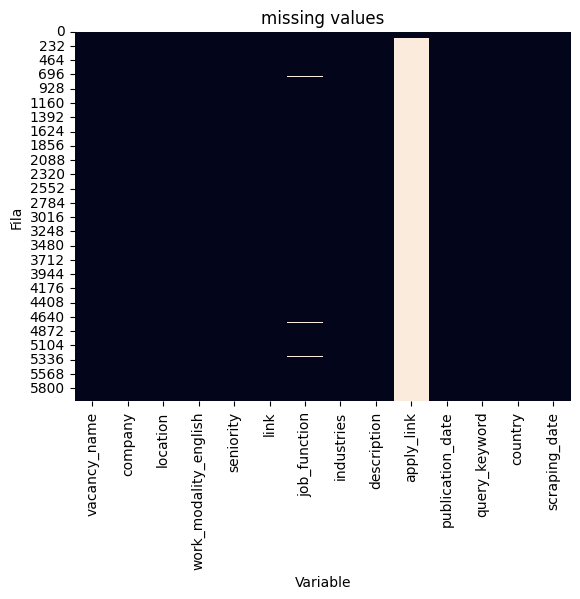

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("missing values")
plt.xlabel('Variable')
plt.ylabel('Fila')

 # categorical variables

Text(0.5, 1.0, "'industries'")

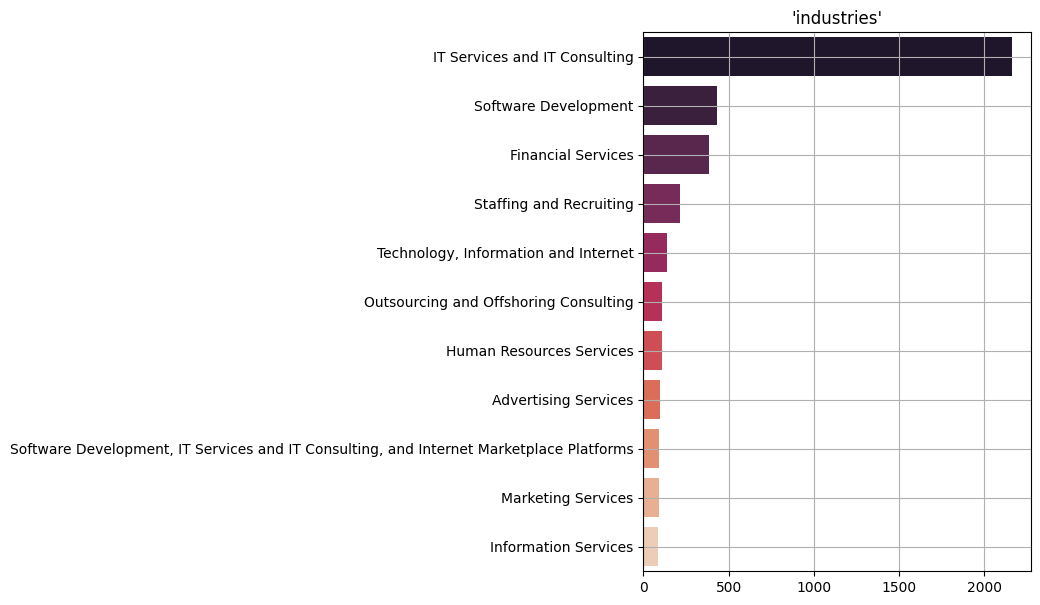

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['industries'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'industries'")

Text(0.5, 1.0, "'company'")

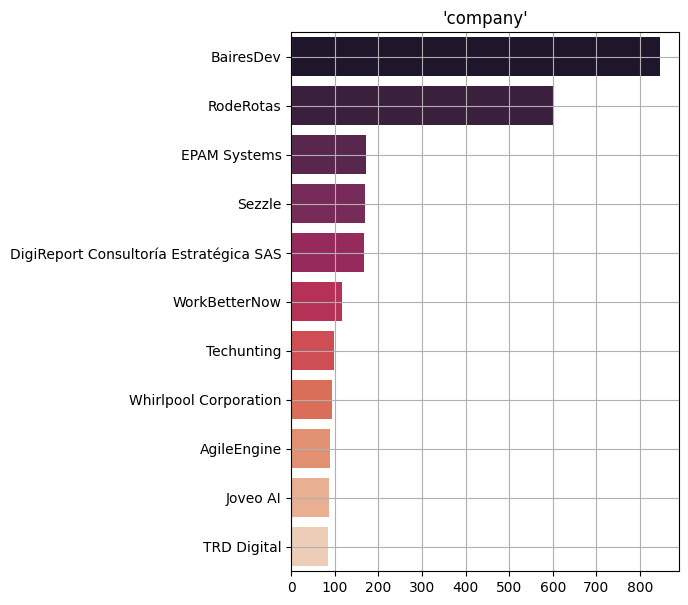

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['company'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'company'")

Text(0.5, 1.0, "'location'")

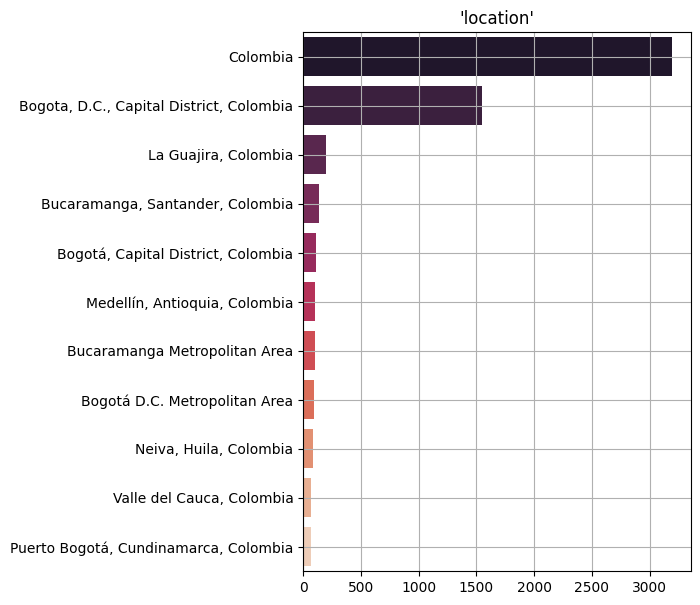

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['location'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'location'")

Text(0.5, 1.0, "'work_modality_english'")

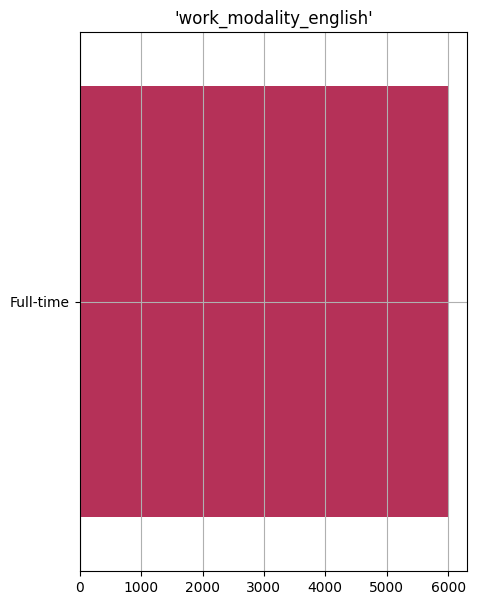

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['work_modality_english'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'work_modality_english'")

Text(0.5, 1.0, "'seniority'")

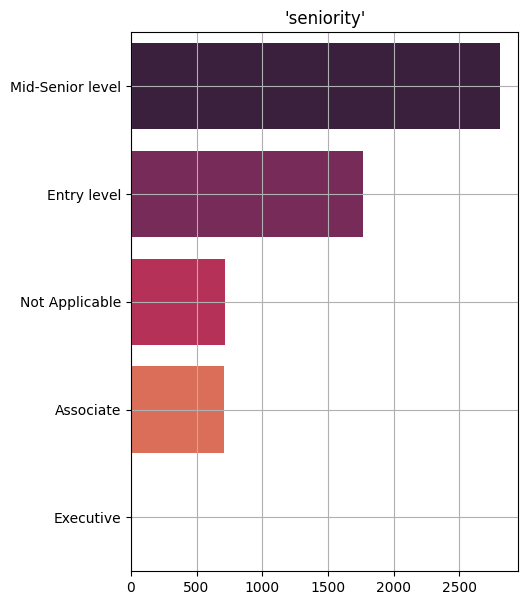

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['seniority'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'seniority'")

Text(0.5, 1.0, "'publication_date'")

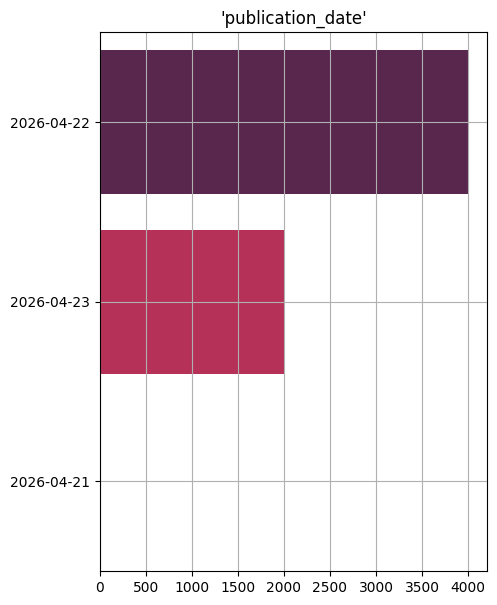

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['publication_date'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'publication_date'")

 # knowledge based filters

In [ ]:
job_seeker = open_json('../data/job_seekers.json')
job_seeker[0].keys()
seniority_criteria = job_seeker[0]['seniority']
location_criteria = job_seeker[0]['location']
work_modality_criteria = job_seeker[0]['work_modality_english']
excluded_companies = ["BairesDev"]

In [ ]:
df_filtered = df[
    (df["seniority"].isin(seniority_criteria)) &  # Filter by seniority
    (df["location"].isin(location_criteria)) &    # Filter by location
    (df["work_modality_english"].isin(work_modality_criteria)) &  # Filter by work modality
    (~df["company"].isin(excluded_companies))     # Exclude specified companies
].copy()
df_filtered.shape

(2754, 14)

 # categorical variables

Text(0.5, 1.0, "'company'")

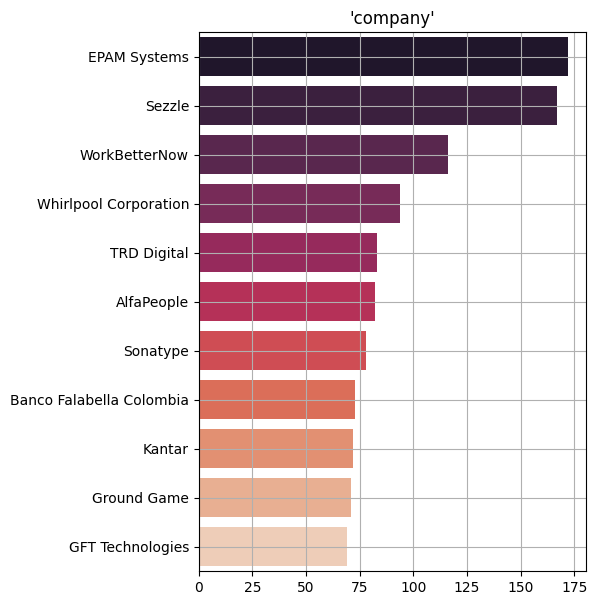

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['company'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'company'")

Text(0.5, 1.0, "'location'")

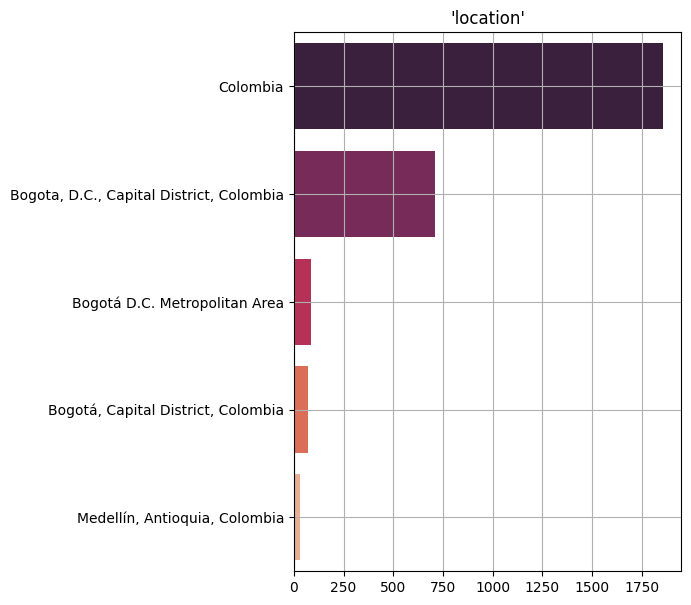

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['location'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'location'")

Text(0.5, 1.0, "'work_modality_english'")

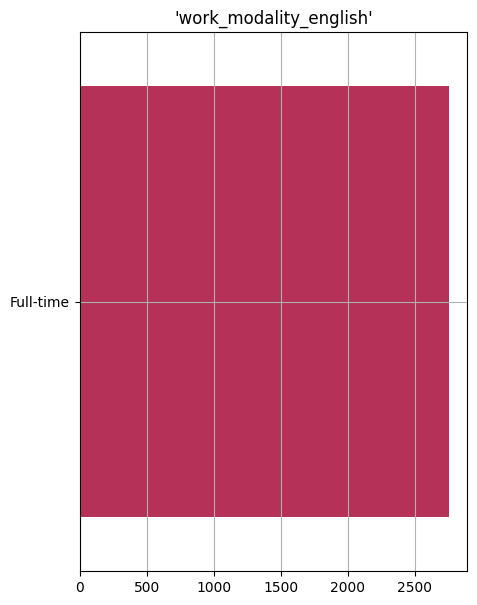

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['work_modality_english'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'work_modality_english'")

Text(0.5, 1.0, "'seniority'")

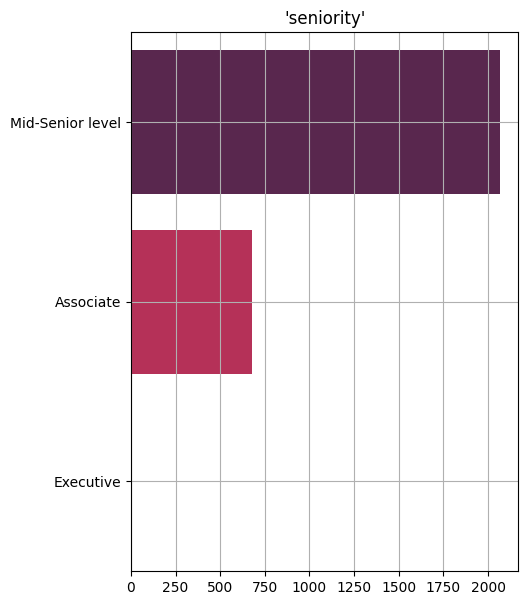

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['seniority'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'seniority'")

Text(0.5, 1.0, "'publication_date'")

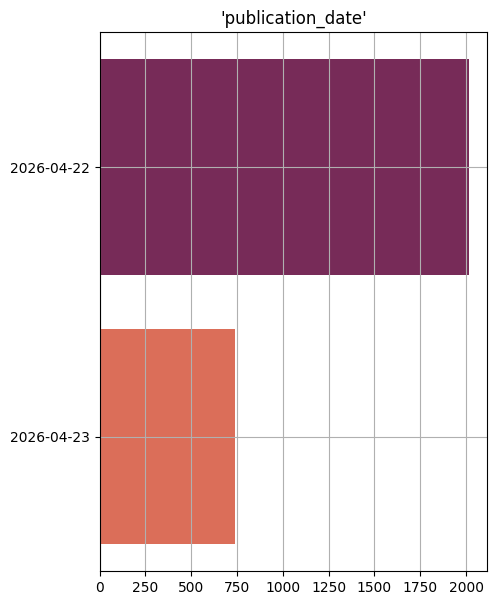

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['publication_date'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'publication_date'")

Text(0.5, 1.0, "'vacancy_name'")

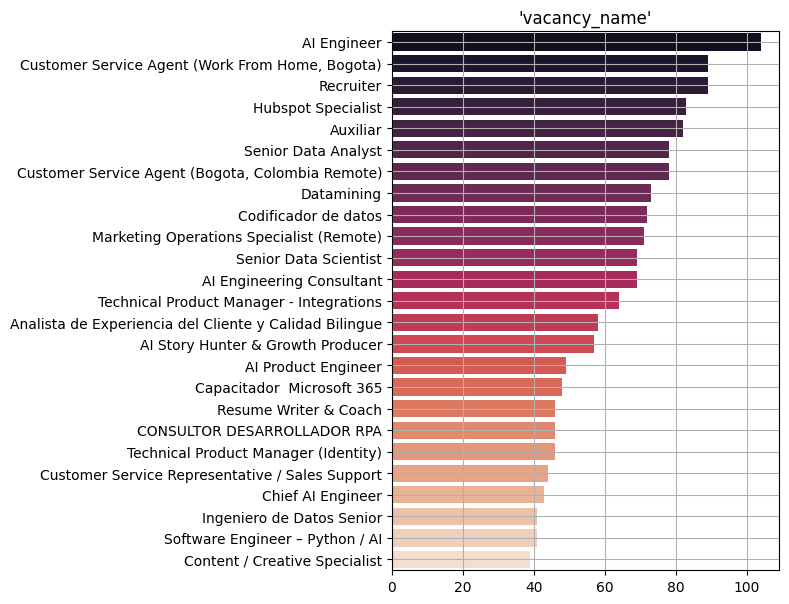

In [ ]:
plt.figure(figsize=(5,7))
df = df_filtered[df_filtered['publication_date'] > (datetime.now() - timedelta(days=3)).strftime('%Y-%m-%d')]
a = pd.DataFrame(df['vacancy_name'].value_counts()[:25])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'vacancy_name'")

 # skills

In [ ]:
df_skills = pd.read_json('../data/general_skills.json')
print(df_skills.shape)
df_skills['skills'] = df_skills['skills'].apply(lambda x: x.lower())
df_skills.drop_duplicates(inplace=True)
print(df_skills.shape)
df_skills.to_json('../data/general_skills.json')

(462, 1)
(462, 1)


 # Job title description file

In [ ]:
industries = [
    'IT Services and IT Consulting',
    'Software Development',
    'Technology, Information and Internet',
    'Business Consulting and Services'
]
df_summary = df_filtered[df_filtered['industries'].isin(industries)][['vacancy_name','description']][:1000].copy()
print(df_summary.shape)
df_summary.to_json('../data/vacancy_name_description.json')

(815, 2)
